In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("train.csv")

print("Dataset chargé avec succès !")
print("Dimensions :", df.shape)

Dataset chargé avec succès !
Dimensions : (1460, 81)


In [2]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.tail()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [5]:
print("Variable cible :", "SalePrice")
print("Nombre de maisons :", len(df))
print("Prix minimum :", df["SalePrice"].min())
print("Prix maximum :", df["SalePrice"].max())
print("Prix moyen :", df["SalePrice"].mean())
print("Prix médian :", df["SalePrice"].median())

Variable cible : SalePrice
Nombre de maisons : 1460
Prix minimum : 34900
Prix maximum : 755000
Prix moyen : 180921.19589041095
Prix médian : 163000.0


In [6]:
df["SalePrice"].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [7]:
missing = df.isnull().sum()

missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [8]:
features = [
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF",
    "FullBath",
    "BedroomAbvGr",
    "YearBuilt"
]

target = "SalePrice"

In [9]:
df[features + [target]].head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,BedroomAbvGr,YearBuilt,SalePrice
0,7,1710,2,856,2,3,2003,208500
1,6,1262,2,1262,2,3,1976,181500
2,7,1786,2,920,2,3,2001,223500
3,7,1717,3,756,1,3,1915,140000
4,8,2198,3,1145,2,4,2000,250000


In [10]:
df[features + [target]].isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
FullBath        0
BedroomAbvGr    0
YearBuilt       0
SalePrice       0
dtype: int64

In [11]:
df[features + [target]].describe()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,BedroomAbvGr,YearBuilt,SalePrice
count,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,6.099315,1515.463699,1.767123,1057.429452,1.565068,2.866438,1971.267808,180921.195890
std,1.382997,525.480383,0.747315,438.705324,0.550916,0.815778,30.202904,79442.502883
min,1.000000,334.000000,0.000000,0.000000,0.000000,0.000000,1872.000000,34900.000000
25%,5.000000,1129.500000,1.000000,795.750000,1.000000,2.000000,1954.000000,129975.000000
50%,6.000000,1464.000000,2.000000,991.500000,2.000000,3.000000,1973.000000,163000.000000
75%,7.000000,1776.750000,2.000000,1298.250000,2.000000,3.000000,2000.000000,214000.000000
max,10.000000,5642.000000,4.000000,6110.000000,3.000000,8.000000,2010.000000,755000.000000


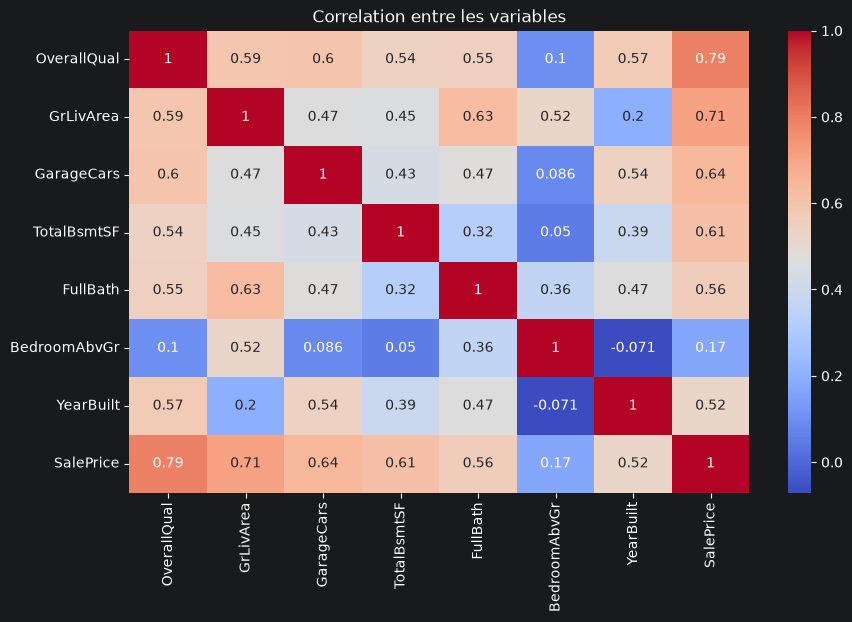

In [12]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df[features + [target]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation entre les variables")
plt.show()

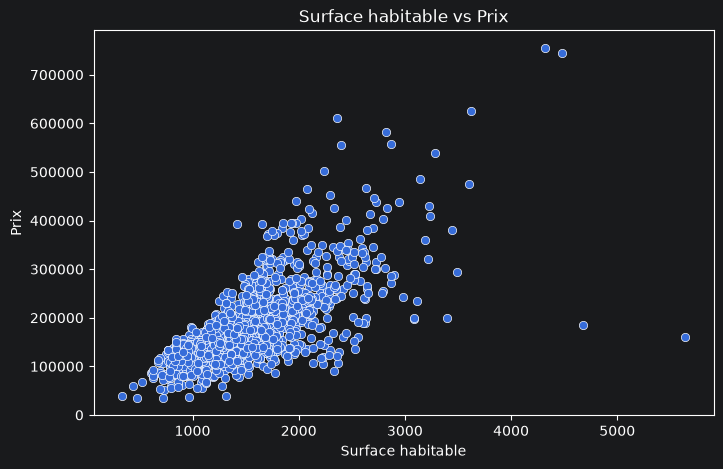

In [13]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="GrLivArea",
    y="SalePrice"
)

plt.title("Surface habitable vs Prix")
plt.xlabel("Surface habitable")
plt.ylabel("Prix")
plt.show()

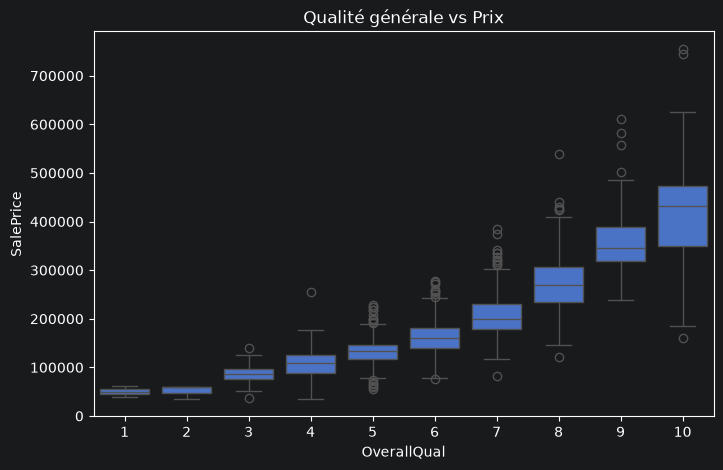

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="OverallQual",
    y="SalePrice"
)

plt.title("Qualité générale vs Prix")
plt.show()

In [15]:
df[features + [target]].isnull().sum()

OverallQual     0
GrLivArea       0
GarageCars      0
TotalBsmtSF     0
FullBath        0
BedroomAbvGr    0
YearBuilt       0
SalePrice       0
dtype: int64

In [16]:
X = df[features]
y = df[target]

print("X :", X.shape)
print("y :", y.shape)

X : (1460, 7)
y : (1460,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1168, 7)
X_test  : (292, 7)
y_train : (1168,)
y_test  : (292,)


In [18]:
X_train.describe()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,FullBath,BedroomAbvGr,YearBuilt
count,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000,1168.000000
mean,6.121575,1527.401541,1.781678,1061.771404,1.577055,2.890411,1970.965753
std,1.367619,524.432686,0.740161,440.676330,0.546912,0.804855,30.675495
min,1.000000,334.000000,0.000000,0.000000,0.000000,0.000000,1872.000000
25%,5.000000,1145.750000,1.000000,796.000000,1.000000,2.000000,1953.000000
50%,6.000000,1473.000000,2.000000,997.500000,2.000000,3.000000,1972.000000
75%,7.000000,1792.000000,2.000000,1299.250000,2.000000,3.000000,2001.000000
max,10.000000,5642.000000,4.000000,6110.000000,3.000000,8.000000,2010.000000


In [19]:
y_train.describe()

count      1168.000000
mean     181441.541952
std       77263.583862
min       34900.000000
25%      130000.000000
50%      165000.000000
75%      214925.000000
max      745000.000000
Name: SalePrice, dtype: float64

In [20]:
print(X.dtypes)

OverallQual     int64
GrLivArea       int64
GarageCars      int64
TotalBsmtSF     int64
FullBath        int64
BedroomAbvGr    int64
YearBuilt       int64
dtype: object


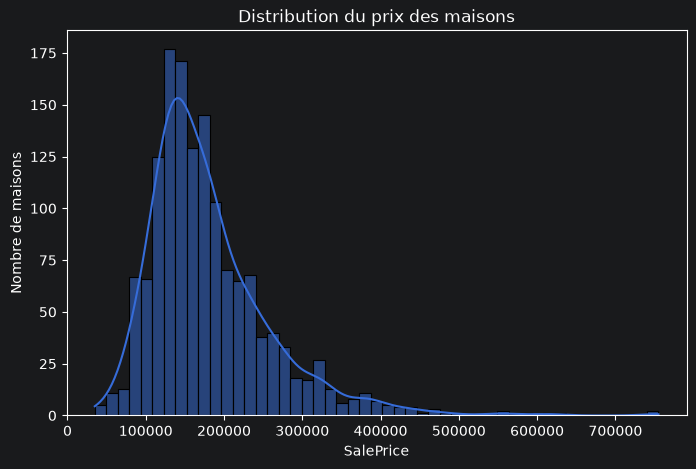

In [21]:
plt.figure(figsize=(8, 5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Distribution du prix des maisons")
plt.xlabel("SalePrice")
plt.ylabel("Nombre de maisons")
plt.show()

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = [mae, rmse, r2]

results_df = pd.DataFrame(
    results,
    index=["MAE", "RMSE", "R²"]
).T

results_df

,MAE,RMSE,R²
Linear Regression,25089.122531,38998.663331,0.801717
Decision Tree,25875.239726,39955.857534,0.791864
Random Forest,19157.419326,28883.538944,0.891236
Gradient Boosting,18792.678134,28121.587134,0.896898


In [23]:
best_name = results_df["R²"].idxmax()
best_model = models[best_name]

print("Meilleur modèle :", best_name)
print("R² :", results_df.loc[best_name, "R²"])

Meilleur modèle : Gradient Boosting
R² : 0.8968983011164566


In [24]:
import joblib

joblib.dump(best_model, "best_model.pkl")

print("Modèle sauvegardé : best_model.pkl")

Modèle sauvegardé : best_model.pkl


In [28]:
sample = pd.DataFrame([{
    "OverallQual": 7,
    "GrLivArea": 1800,
    "GarageCars": 2,
    "TotalBsmtSF": 1000,
    "FullBath": 2,
    "BedroomAbvGr": 3,
    "YearBuilt": 2005
}])

prediction = best_model.predict(sample)

print("Prix prédit :", round(prediction[0], 2))

Prix prédit : 206335.99
